Extracts the pose keypoints (joints) of pedestrians using the pre-trained YOLO26 pose model. \
https://docs.ultralytics.com/tasks/pose/

## Pose Output Storage Format

The pose inference output is saved to `pedestrian_poses.pkl` as a Python dictionary.

- Top-level key: `"video_id:pedestrian_id"` (example: `video_0001:0_1_3b`)
- Top-level value: list of per-frame pose records for that pedestrian track

Each per-frame record contains:

- `video_id`: JAAD video id
- `pedestrian_id`: pedestrian id from JAAD annotations
- `frame_id`: frame index in the video clip
- `bbox_xyxy`: bounding box `[x1, y1, x2, y2]` in full-frame coordinates
- `keypoints_xy`: pose keypoints as `[[x, y], ...]` in full-frame coordinates
- `keypoints_conf`: per-keypoint confidence list (or `None` if unavailable)

Download the extracted pose keypoints here: https://drive.google.com/file/d/19aaBSTmzji-Jw5PXO0YQYSyZ61-KnzrC/view?usp=drive_link

In [2]:
from jaad_data import JAAD

jaad_api = JAAD(data_path=".")
db = jaad_api.generate_database()

---------------------------------------------------------
Generating database for jaad
jaad database loaded from c:\Users\gordo\Desktop\CS3264\Project\CS3264_Team6_Project\data_cache\jaad_database.pkl


In [1]:
from ultralytics import YOLO

model = YOLO("yolo26s-pose.pt")

In [ ]:
from collections import defaultdict
import cv2
import os
import pickle
from pathlib import Path


def _clip_bbox(x1, y1, x2, y2, w, h):
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w - 1))
    y2 = max(0, min(int(y2), h - 1))
    return x1, y1, x2, y2


def extract_poses_from_videos(model, db, output_path="./pedestrian_poses.pkl", conf=0.25, device=0, save_every_video=True):
    poses_by_track = defaultdict(list)
    clip_files = sorted(
        f for f in os.listdir(jaad_api._clips_path)
        if f.lower().endswith(".mp4")
    )

    for i, clip_file in enumerate(clip_files, start=1):
        vid = os.path.splitext(clip_file)[0]
        clip_path = os.path.join(jaad_api._clips_path, clip_file)

        if vid not in db:
            print(f"[{i}/{len(clip_files)}] [SKIP] {vid}: no DB entry")
            continue

        video = db[vid]

        # Build frame -> list of pedestrian targets from DB annotations.
        targets_by_frame = defaultdict(list)
        for pid, ped in video["ped_annotations"].items():
            frames = ped.get("frames", [])
            bboxes = ped.get("bbox", [])
            if not frames or not bboxes:
                continue
            for frame_id, bbox in zip(frames, bboxes):
                targets_by_frame[int(frame_id)].append((pid, bbox))

        if not targets_by_frame:
            print(f"[{i}/{len(clip_files)}] [SKIP] {vid}: no pedestrian targets")
            continue

        cap = cv2.VideoCapture(clip_path)
        if not cap.isOpened():
            print(f"[{i}/{len(clip_files)}] [SKIP] cannot open {clip_path}")
            continue

        frame_idx = 0
        infer_count = 0
        target_frames = set(targets_by_frame.keys())
        max_target_frame = max(target_frames)

        while True:
            ok, frame = cap.read()
            if not ok:
                break

            if frame_idx > max_target_frame:
                break

            if frame_idx in targets_by_frame:
                h, w = frame.shape[:2]
                for pid, bbox in targets_by_frame[frame_idx]:
                    x1, y1, x2, y2 = bbox
                    x1, y1, x2, y2 = _clip_bbox(x1, y1, x2, y2, w, h)
                    if x2 <= x1 or y2 <= y1:
                        continue

                    crop = frame[y1:y2, x1:x2]
                    if crop.size == 0:
                        continue

                    result = model.predict(crop, conf=conf, device=device, verbose=False)
                    if not result:
                        continue

                    r = result[0]
                    if r.keypoints is None or r.keypoints.xy is None or len(r.keypoints.xy) == 0:
                        continue

                    # If multiple people are detected in crop, select highest confidence one.
                    det_idx = 0
                    if r.boxes is not None and r.boxes.conf is not None and len(r.boxes.conf) > 0:
                        det_idx = int(r.boxes.conf.argmax().item())

                    kpts_xy = r.keypoints.xy[det_idx].cpu().numpy()
                    kpts_conf = None
                    if hasattr(r.keypoints, "conf") and r.keypoints.conf is not None:
                        kpts_conf = r.keypoints.conf[det_idx].cpu().numpy()

                    # Convert crop-local keypoints back to full-frame coordinates.
                    kpts_xy[:, 0] += x1
                    kpts_xy[:, 1] += y1

                    # Storage format (pickled dict):
                    # poses_by_track["video_id:pedestrian_id"] -> list of per-frame records
                    # each record = {video_id, pedestrian_id, frame_id, bbox_xyxy, keypoints_xy, keypoints_conf}
                    track_id = f"{vid}:{pid}"
                    poses_by_track[track_id].append({
                        "video_id": vid,
                        "pedestrian_id": pid,
                        "frame_id": frame_idx,
                        "bbox_xyxy": [x1, y1, x2, y2],
                        "keypoints_xy": kpts_xy.tolist(),
                        "keypoints_conf": kpts_conf.tolist() if kpts_conf is not None else None,
                    })
                    infer_count += 1

            frame_idx += 1

        cap.release()
        print(f"[{i}/{len(clip_files)}] {vid}: inferred {infer_count} pedestrian poses")

        if save_every_video:
            Path(output_path).parent.mkdir(parents=True, exist_ok=True)
            with open(output_path, "wb") as f:
                pickle.dump(dict(poses_by_track), f, protocol=pickle.HIGHEST_PROTOCOL)

    # Final save
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "wb") as f:
        pickle.dump(dict(poses_by_track), f, protocol=pickle.HIGHEST_PROTOCOL)

    return dict(poses_by_track)


poses_by_track = extract_poses_from_videos(
    model=model,
    db=db,
    output_path="./pedestrian_poses.pkl",
    conf=0.25,
    device=0,  # change to "cpu" if CUDA is unavailable
    save_every_video=True,
)

print("tracks with pose:", len(poses_by_track))
if poses_by_track:
    first_track = next(iter(poses_by_track.keys()))
    print("example track:", first_track)
    print("frames with pose for example:", len(poses_by_track[first_track]))

[1/346] video_0001: inferred 914 pedestrian poses
[2/346] video_0002: inferred 310 pedestrian poses
[3/346] video_0003: inferred 273 pedestrian poses
[4/346] video_0004: inferred 265 pedestrian poses
[5/346] video_0005: inferred 831 pedestrian poses
[6/346] video_0006: inferred 1953 pedestrian poses
[7/346] video_0007: inferred 157 pedestrian poses
[8/346] video_0008: inferred 100 pedestrian poses
[9/346] video_0009: inferred 120 pedestrian poses
[10/346] video_0010: inferred 132 pedestrian poses
[11/346] video_0011: inferred 177 pedestrian poses
[12/346] video_0012: inferred 104 pedestrian poses
[13/346] [SKIP] video_0013: no pedestrian targets
[14/346] video_0014: inferred 187 pedestrian poses
[15/346] video_0015: inferred 236 pedestrian poses
[16/346] video_0016: inferred 753 pedestrian poses
[17/346] video_0017: inferred 336 pedestrian poses
[18/346] [SKIP] video_0018: no pedestrian targets
[19/346] video_0019: inferred 291 pedestrian poses
[20/346] video_0020: inferred 1355 pedest

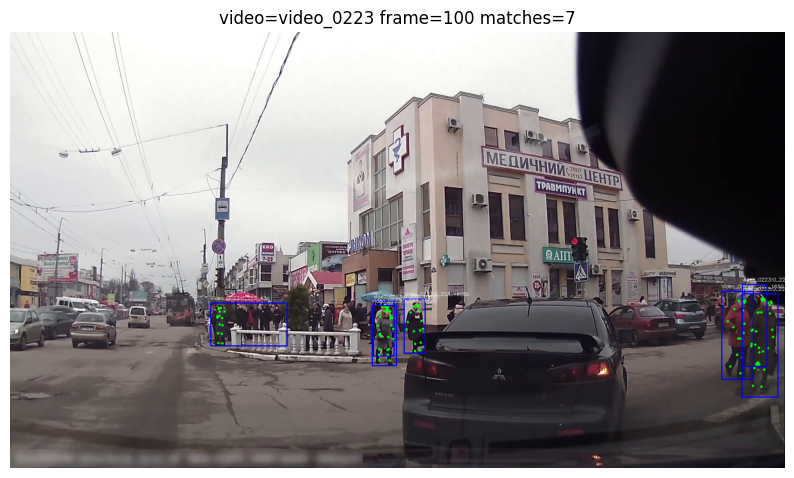

In [3]:
# Sanity check for pose inference

import cv2
import os
import pickle
import matplotlib.pyplot as plt


def visualize_pose_at(video_id, frame_id, pkl_path="./pedestrian_poses.pkl", pedestrian_id=None, draw_all_matches=True):
    with open(pkl_path, "rb") as f:
        poses_by_track = pickle.load(f)

    # Collect matching records from the requested video/frame.
    matches = []
    for track_id, records in poses_by_track.items():
        for rec in records:
            if rec.get("video_id") != video_id:
                continue
            if int(rec.get("frame_id", -1)) != int(frame_id):
                continue
            if pedestrian_id is not None and rec.get("pedestrian_id") != pedestrian_id:
                continue
            matches.append((track_id, rec))

    if not matches:
        print(f"No pose record found for video={video_id}, frame={frame_id}, pedestrian_id={pedestrian_id}")
        return

    clip_path = os.path.join(jaad_api._clips_path, f"{video_id}.mp4")
    cap = cv2.VideoCapture(clip_path)
    if not cap.isOpened():
        print(f"Cannot open video: {clip_path}")
        return

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_id))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        print(f"Cannot read frame {frame_id} from {clip_path}")
        return

    # Draw selected records.
    to_draw = matches if draw_all_matches else [matches[0]]
    for track_id, rec in to_draw:
        bbox = rec["bbox_xyxy"]
        kpts = rec["keypoints_xy"]

        x1, y1, x2, y2 = map(int, bbox)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(frame, track_id, (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

        for x, y in kpts:
            if x > 0 and y > 0:
                cv2.circle(frame, (int(x), int(y)), 3, (0, 255, 0), -1)

    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"video={video_id} frame={frame_id} matches={len(to_draw)}")
    plt.axis("off")
    plt.show()


video_id = "video_0223"
frame_id = 100
pedestrian_id = None  # e.g. "0b" or None
visualize_pose_at(video_id, frame_id, "./pedestrian_poses.pkl", pedestrian_id=pedestrian_id, draw_all_matches=True)